### Prerequsite - Upgrade Scikit Learn
The current workspace has scikit-learn v0.19.1 installed. However, you can upgrade scikit-learn to 0.24.x. and use this [OneHotEncoder](https://scikit-learn.org/0.21/modules/generated/sklearn.preprocessing.OneHotEncoder.html) library. 


In [1]:
import sklearn
print('The scikit-learn version is {}.'.format(sklearn.__version__))

The scikit-learn version is 0.24.2.


In [2]:
import os
os.environ['PATH'] = f"{os.environ['PATH']}:/root/.local/bin"

In [3]:
!python -m pip install --upgrade scikit-learn
import sklearn
print('The scikit-learn version is {}.'.format(sklearn.__version__))

Requirement already up-to-date: scikit-learn in /opt/conda/lib/python3.6/site-packages (0.24.2)
The scikit-learn version is 0.24.2.


In [4]:
# Now you can import and use OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
# your code goes here

In [5]:
# Similarly, should you need any other package, they can install it as:
!python -m pip install 'tensorflow-tensorboard<0.2.0,>=0.1.0'

# Project: Identify Customer Segments

In this project, you will apply unsupervised learning techniques to identify segments of the population that form the core customer base for a mail-order sales company in Germany. These segments can then be used to direct marketing campaigns towards audiences that will have the highest expected rate of returns. The data that you will use has been provided by our partners at Bertelsmann Arvato Analytics, and represents a real-life data science task.

This notebook will help you complete this task by providing a framework within which you will perform your analysis steps. In each step of the project, you will see some text describing the subtask that you will perform, followed by one or more code cells for you to complete your work. **Feel free to add additional code and markdown cells as you go along so that you can explore everything in precise chunks.** The code cells provided in the base template will outline only the major tasks, and will usually not be enough to cover all of the minor tasks that comprise it.

It should be noted that while there will be precise guidelines on how you should handle certain tasks in the project, there will also be places where an exact specification is not provided. **There will be times in the project where you will need to make and justify your own decisions on how to treat the data.** These are places where there may not be only one way to handle the data. In real-life tasks, there may be many valid ways to approach an analysis task. One of the most important things you can do is clearly document your approach so that other scientists can understand the decisions you've made.

At the end of most sections, there will be a Markdown cell labeled **Discussion**. In these cells, you will report your findings for the completed section, as well as document the decisions that you made in your approach to each subtask. **Your project will be evaluated not just on the code used to complete the tasks outlined, but also your communication about your observations and conclusions at each stage.**

In [6]:
# import libraries here; add more as necessary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# magic word for producing visualizations in notebook
%matplotlib inline

'''
Import note: The classroom currently uses sklearn version 0.19.
If you need to use an imputer, it is available in sklearn.preprocessing.Imputer,
instead of sklearn.impute as in newer versions of sklearn.
'''
pd.options.display.max_rows = None
pd.options.display.max_columns = None

### Step 0: Load the Data

There are four files associated with this project (not including this one):

- `Udacity_AZDIAS_Subset.csv`: Demographics data for the general population of Germany; 891211 persons (rows) x 85 features (columns).
- `Udacity_CUSTOMERS_Subset.csv`: Demographics data for customers of a mail-order company; 191652 persons (rows) x 85 features (columns).
- `Data_Dictionary.md`: Detailed information file about the features in the provided datasets.
- `AZDIAS_Feature_Summary.csv`: Summary of feature attributes for demographics data; 85 features (rows) x 4 columns

Each row of the demographics files represents a single person, but also includes information outside of individuals, including information about their household, building, and neighborhood. You will use this information to cluster the general population into groups with similar demographic properties. Then, you will see how the people in the customers dataset fit into those created clusters. The hope here is that certain clusters are over-represented in the customers data, as compared to the general population; those over-represented clusters will be assumed to be part of the core userbase. This information can then be used for further applications, such as targeting for a marketing campaign.

To start off with, load in the demographics data for the general population into a pandas DataFrame, and do the same for the feature attributes summary. Note for all of the `.csv` data files in this project: they're semicolon (`;`) delimited, so you'll need an additional argument in your [`read_csv()`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html) call to read in the data properly. Also, considering the size of the main dataset, it may take some time for it to load completely.

Once the dataset is loaded, it's recommended that you take a little bit of time just browsing the general structure of the dataset and feature summary file. You'll be getting deep into the innards of the cleaning in the first major step of the project, so gaining some general familiarity can help you get your bearings.

In [7]:
# Load in the general demographics data.
azdias = pd.read_csv('Udacity_AZDIAS_Subset.csv', sep=';')

# Load in the feature summary file.
feat_info = pd.read_csv('AZDIAS_Feature_Summary.csv', sep=';')

In [8]:
# Check the structure of the data after it's loaded (e.g. print the number of
# rows and columns, print the first few rows).
print(azdias.shape)
azdias.head()

(891221, 85)


,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,4,0,10.0,0,-1,15.0,4.0,2.0,2.0,1.0,1.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,1,1996,10.0,0,3,21.0,6.0,5.0,3.0,2.0,1.0,1,14,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3,1.0,0.0,2,5,0.0,2.0,0.0,6.0,NaN,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,W,4.0,8,8A,51,0.0,0.0,0.0,2.0,5.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,1,1979,10.0,1,3,3.0,1.0,1.0,1.0,3.0,2.0,1,15,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2,0.0,0.0,1,5,17.0,1.0,0.0,4.0,NaN,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,W,2.0,4,4C,24,1.0,3.0,1.0,0.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,2,4,2,2.0,4,2,5,2,1,2,6,1957,1.0,0,2,0.0,0.0,0.0,0.0,9.0,4.0,1,8,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1,0.0,0.0,1,3,13.0,0.0,0.0,1.0,NaN,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,W,7.0,2,2A,12,4.0,1.0,0.0,0.0,1.0,4.0,4.0,2.0,6.0,4.0,0.0,4.0,1.0,0.0,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,-1,3,1,5.0,4,3,4,1,3,2,5,1963,5.0,0,3,32.0,10.0,10.0,5.0,3.0,2.0,1,8,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2,0.0,0.0,2,4,20.0,4.0,0.0,5.0,1.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,W,3.0,6,6B,43,1.0,4.0,1.0,0.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0


In [9]:
print(feat_info.shape)
feat_info.head()

(85, 4)


,attribute,information_level,type,missing_or_unknown
0,AGER_TYP,person,categorical,"[-1,0]"
1,ALTERSKATEGORIE_GROB,person,ordinal,"[-1,0,9]"
2,ANREDE_KZ,person,categorical,"[-1,0]"
3,CJT_GESAMTTYP,person,categorical,[0]
4,FINANZ_MINIMALIST,person,ordinal,[-1]


In [10]:
print(azdias.shape)
azdias.head()

(891221, 85)


,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,4,0,10.0,0,-1,15.0,4.0,2.0,2.0,1.0,1.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,1,1996,10.0,0,3,21.0,6.0,5.0,3.0,2.0,1.0,1,14,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3,1.0,0.0,2,5,0.0,2.0,0.0,6.0,NaN,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,W,4.0,8,8A,51,0.0,0.0,0.0,2.0,5.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,1,1979,10.0,1,3,3.0,1.0,1.0,1.0,3.0,2.0,1,15,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2,0.0,0.0,1,5,17.0,1.0,0.0,4.0,NaN,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,W,2.0,4,4C,24,1.0,3.0,1.0,0.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,2,4,2,2.0,4,2,5,2,1,2,6,1957,1.0,0,2,0.0,0.0,0.0,0.0,9.0,4.0,1,8,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1,0.0,0.0,1,3,13.0,0.0,0.0,1.0,NaN,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,W,7.0,2,2A,12,4.0,1.0,0.0,0.0,1.0,4.0,4.0,2.0,6.0,4.0,0.0,4.0,1.0,0.0,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,-1,3,1,5.0,4,3,4,1,3,2,5,1963,5.0,0,3,32.0,10.0,10.0,5.0,3.0,2.0,1,8,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2,0.0,0.0,2,4,20.0,4.0,0.0,5.0,1.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,W,3.0,6,6B,43,1.0,4.0,1.0,0.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0


> **Tip**: Add additional cells to keep everything in reasonably-sized chunks! Keyboard shortcut `esc --> a` (press escape to enter command mode, then press the 'A' key) adds a new cell before the active cell, and `esc --> b` adds a new cell after the active cell. If you need to convert an active cell to a markdown cell, use `esc --> m` and to convert to a code cell, use `esc --> y`. 

## Step 1: Preprocessing

### Step 1.1: Assess Missing Data

The feature summary file contains a summary of properties for each demographics data column. You will use this file to help you make cleaning decisions during this stage of the project. First of all, you should assess the demographics data in terms of missing data. Pay attention to the following points as you perform your analysis, and take notes on what you observe. Make sure that you fill in the **Discussion** cell with your findings and decisions at the end of each step that has one!

#### Step 1.1.1: Convert Missing Value Codes to NaNs
The fourth column of the feature attributes summary (loaded in above as `feat_info`) documents the codes from the data dictionary that indicate missing or unknown data. While the file encodes this as a list (e.g. `[-1,0]`), this will get read in as a string object. You'll need to do a little bit of parsing to make use of it to identify and clean the data. Convert data that matches a 'missing' or 'unknown' value code into a numpy NaN value. You might want to see how much data takes on a 'missing' or 'unknown' code, and how much data is naturally missing, as a point of interest.

**As one more reminder, you are encouraged to add additional cells to break up your analysis into manageable chunks.**

In [11]:
# Identify missing or unknown data values and convert them to NaNs.

for row in feat_info.itertuples():
    attribute = row.attribute
    missing_vals_str = row.missing_or_unknown

    # Parse the string like "[-1,0]" into a list of individual codes
    codes = missing_vals_str.strip('[]').split(',')
    codes = [c for c in codes if c != '']

    parsed_codes = []
    for c in codes:
        try:
            parsed_codes.append(int(c))
        except ValueError:
            parsed_codes.append(c)

    if attribute in azdias.columns and len(parsed_codes) > 0:
        azdias.loc[azdias[attribute].isin(parsed_codes), attribute] = np.nan

In [12]:
azdias.isnull().sum().sort_values(ascending=False).head(10)

TITEL_KZ          889061
AGER_TYP          685843
KK_KUNDENTYP      584612
KBA05_BAUMAX      476524
GEBURTSJAHR       392318
ALTER_HH          310267
REGIOTYP          158064
KKK               158064
W_KEIT_KIND_HH    147988
KBA05_ANTG4       133324
dtype: int64

#### Step 1.1.2: Assess Missing Data in Each Column

How much missing data is present in each column? There are a few columns that are outliers in terms of the proportion of values that are missing. You will want to use matplotlib's [`hist()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html) function to visualize the distribution of missing value counts to find these columns. Identify and document these columns. While some of these columns might have justifications for keeping or re-encoding the data, for this project you should just remove them from the dataframe. (Feel free to make remarks about these outlier columns in the discussion, however!)

For the remaining features, are there any patterns in which columns have, or share, missing data?

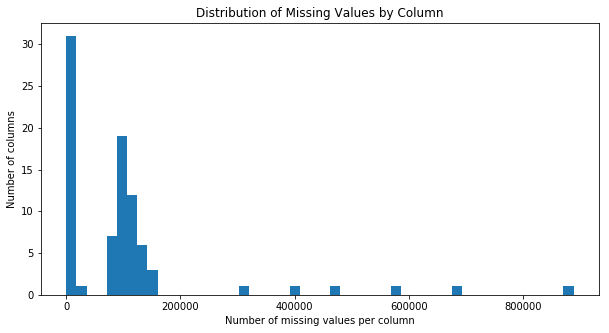

In [13]:
# Perform an assessment of how much missing data there is in each column of the
# dataset.
missing_counts = azdias.isnull().sum()

plt.figure(figsize=(10,5))
plt.hist(missing_counts, bins=50)
plt.xlabel('Number of missing values per column')
plt.ylabel('Number of columns')
plt.title('Distribution of Missing Values by Column')
plt.show()


Beyond these outlier columns, examining the correlation of missingness across the remaining columns revealed several groups of features that are missing in perfect lockstep (correlation of 1.0), including CJT_GESAMTTYP/GFK_URLAUBERTYP, the CAMEO_DEU_2015/CAMEO_DEUG_2015/CAMEO_INTL_2015 trio, ARBEIT/RELAT_AB, OST_WEST_KZ/WOHNLAGE/MIN_GEBAEUDEJAHR/GEBAEUDETYP, ANZ_TITEL/ANZ_PERSONEN/WOHNDAUER_2008, and the PLZ8_ANTG1-4 group. This suggests these features are drawn from the same underlying data sources (e.g. building-level or regional records), so records missing one value in a group are missing the entire group together, rather than missingness occurring independently at random across columns.

In [14]:
# Investigate patterns in missing data across columns (correlation of missingness)
missing_matrix = azdias.isnull().astype(int)
missing_corr = missing_matrix.corr()

# Find highly correlated missingness pairs (excluding self-correlation)
high_corr_pairs = missing_corr.where(np.triu(np.ones(missing_corr.shape), k=1).astype(bool))
high_corr_pairs = high_corr_pairs.stack()
high_corr_pairs = high_corr_pairs[high_corr_pairs > 0.8].sort_values(ascending=False)
print(high_corr_pairs.head(15))

CJT_GESAMTTYP     GFK_URLAUBERTYP     1.0
CAMEO_DEU_2015    CAMEO_INTL_2015     1.0
CAMEO_DEUG_2015   CAMEO_DEU_2015      1.0
ARBEIT            RELAT_AB            1.0
OST_WEST_KZ       WOHNLAGE            1.0
MIN_GEBAEUDEJAHR  WOHNLAGE            1.0
                  OST_WEST_KZ         1.0
GEBAEUDETYP       WOHNLAGE            1.0
                  OST_WEST_KZ         1.0
                  MIN_GEBAEUDEJAHR    1.0
ANZ_TITEL         WOHNDAUER_2008      1.0
ANZ_PERSONEN      WOHNDAUER_2008      1.0
PLZ8_ANTG1        PLZ8_ANTG2          1.0
                  PLZ8_ANTG3          1.0
                  PLZ8_ANTG4          1.0
dtype: float64


In [15]:
# Investigate patterns in the amount of missing data in each column.

outlier_columns = missing_counts[missing_counts > 200000].index.tolist()
print("Outlier columns (>200,000 missing):")
print(outlier_columns)
print()
print(missing_counts[outlier_columns].sort_values(ascending=False))

Outlier columns (>200,000 missing):
['AGER_TYP', 'GEBURTSJAHR', 'TITEL_KZ', 'ALTER_HH', 'KK_KUNDENTYP', 'KBA05_BAUMAX']

TITEL_KZ        889061
AGER_TYP        685843
KK_KUNDENTYP    584612
KBA05_BAUMAX    476524
GEBURTSJAHR     392318
ALTER_HH        310267
dtype: int64


In [16]:
# Remove the outlier columns from the dataset. (You'll perform other data
# engineering tasks such as re-encoding and imputation later.)
azdias = azdias.drop(columns=outlier_columns)
print(azdias.shape)


(891221, 79)


#### Discussion 1.1.2: Assess Missing Data in Each Column

A histogram of missing value counts per column revealed a clear break in the distribution: most columns had fewer than roughly 150,000 missing values, while six columns stood out as outliers with 300,000 to nearly 890,000 missing values (out of 891,221 total rows). These six columns were TITEL_KZ, AGER_TYP, KK_KUNDENTYP, KBA05_BAUMAX, GEBURTSJAHR, and ALTER_HH. TITEL_KZ in particular was missing for nearly 100% of rows. Because these columns had disproportionately large amounts of missing data compared to the rest of the dataset, they were removed from further analysis using a threshold of 200,000 missing values, leaving 79 of the original 85 columns.
Beyond these outlier columns, examining the correlation of missingness across the remaining columns revealed several groups of features that are missing in perfect lockstep (correlation of 1.0), including CJT_GESAMTTYP/GFK_URLAUBERTYP, the CAMEO_DEU_2015/CAMEO_DEUG_2015/CAMEO_INTL_2015 trio, ARBEIT/RELAT_AB, OST_WEST_KZ/WOHNLAGE/MIN_GEBAEUDEJAHR/GEBAEUDETYP, ANZ_TITEL/ANZ_PERSONEN/WOHNDAUER_2008, and the PLZ8_ANTG1-4 group. This suggests these features are drawn from the same underlying data sources (e.g. building-level or regional records), so records missing one value in a group are missing the entire group together, rather than missingness occurring independently at random across columns.

#### Step 1.1.3: Assess Missing Data in Each Row

Now, you'll perform a similar assessment for the rows of the dataset. How much data is missing in each row? As with the columns, you should see some groups of points that have a very different numbers of missing values. Divide the data into two subsets: one for data points that are above some threshold for missing values, and a second subset for points below that threshold.

In order to know what to do with the outlier rows, we should see if the distribution of data values on columns that are not missing data (or are missing very little data) are similar or different between the two groups. Select at least five of these columns and compare the distribution of values.
- You can use seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) function to create a bar chart of code frequencies and matplotlib's [`subplot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.subplot.html) function to put bar charts for the two subplots side by side.
- To reduce repeated code, you might want to write a function that can perform this comparison, taking as one of its arguments a column to be compared.

Depending on what you observe in your comparison, this will have implications on how you approach your conclusions later in the analysis. If the distributions of non-missing features look similar between the data with many missing values and the data with few or no missing values, then we could argue that simply dropping those points from the analysis won't present a major issue. On the other hand, if the data with many missing values looks very different from the data with few or no missing values, then we should make a note on those data as special. We'll revisit these data later on. **Either way, you should continue your analysis for now using just the subset of the data with few or no missing values.**

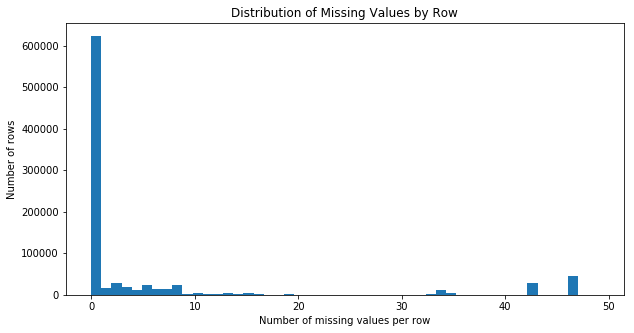

In [17]:
# How much data is missing in each row of the dataset?
row_missing_counts = azdias.isnull().sum(axis=1)

plt.figure(figsize=(10,5))
plt.hist(row_missing_counts, bins=50)
plt.xlabel('Number of missing values per row')
plt.ylabel('Number of rows')
plt.title('Distribution of Missing Values by Row')
plt.show()

In [18]:
# Write code to divide the data into two subsets based on the number of missing
# values in each row.

azdias_low_missing = azdias[row_missing_counts <= 20].copy()
azdias_high_missing = azdias[row_missing_counts > 20].copy()

print("Low missing subset:", azdias_low_missing.shape)
print("High missing subset:", azdias_high_missing.shape)

Low missing subset: (797426, 79)
High missing subset: (93795, 79)


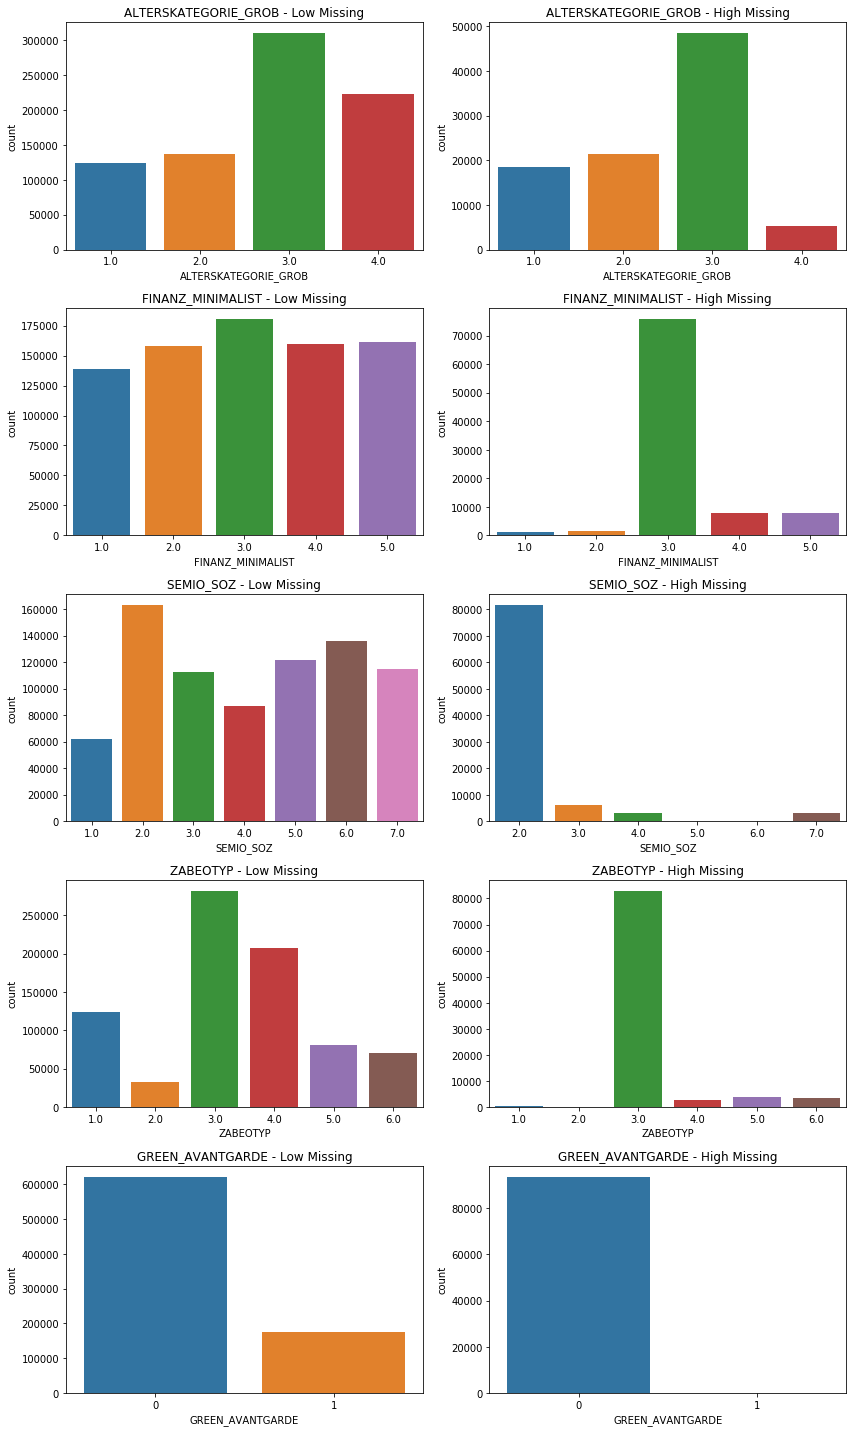

In [19]:
# Compare the distribution of values for at least five columns where there are
# no or few missing values, between the two subsets.

compare_cols = ['ALTERSKATEGORIE_GROB', 'FINANZ_MINIMALIST', 'SEMIO_SOZ', 'ZABEOTYP', 'GREEN_AVANTGARDE']

fig, axes = plt.subplots(len(compare_cols), 2, figsize=(12, 4*len(compare_cols)))

for i, col in enumerate(compare_cols):
    sns.countplot(x=azdias_low_missing[col], ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} - Low Missing')
    
    sns.countplot(x=azdias_high_missing[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} - High Missing')

plt.tight_layout()
plt.show()


#### Discussion 1.1.3: Assess Missing Data in Each Row

Splitting the data using a threshold of 20 missing values per row produced two clearly distinct groups. When comparing distributions of columns with little to no missing data, the high-missing subset showed collapsed, homogeneous responses (for example, nearly all rows had FINANZ_MINIMALIST = 3.0, SEMIO_SOZ = 2.0, ZABEOTYP = 3.0, and GREEN_AVANTGARDE = 0), while the low-missing subset showed a much more natural spread across categories. This suggests the high-missing rows are not simply a random sample with more missing data, but likely represent a distinct, lower-quality response pattern (possibly incomplete surveys or default/placeholder values). Because of this qualitative difference, the high-missing rows are set aside and the remaining analysis proceeds using only the low-missing subset (azdias_low_missing).

### Step 1.2: Select and Re-Encode Features

Checking for missing data isn't the only way in which you can prepare a dataset for analysis. Since the unsupervised learning techniques to be used will only work on data that is encoded numerically, you need to make a few encoding changes or additional assumptions to be able to make progress. In addition, while almost all of the values in the dataset are encoded using numbers, not all of them represent numeric values. Check the third column of the feature summary (`feat_info`) for a summary of types of measurement.
- For numeric and interval data, these features can be kept without changes.
- Most of the variables in the dataset are ordinal in nature. While ordinal values may technically be non-linear in spacing, make the simplifying assumption that the ordinal variables can be treated as being interval in nature (that is, kept without any changes).
- Special handling may be necessary for the remaining two variable types: categorical, and 'mixed'.

In the first two parts of this sub-step, you will perform an investigation of the categorical and mixed-type features and make a decision on each of them, whether you will keep, drop, or re-encode each. Then, in the last part, you will create a new data frame with only the selected and engineered columns.

Data wrangling is often the trickiest part of the data analysis process, and there's a lot of it to be done here. But stick with it: once you're done with this step, you'll be ready to get to the machine learning parts of the project!

In [20]:
# How many features are there of each data type?

# Only consider features still present in our cleaned dataframe
feat_info_remaining = feat_info[feat_info['attribute'].isin(azdias_low_missing.columns)]
print(feat_info_remaining['type'].value_counts())

ordinal        49
categorical    18
mixed           6
numeric         6
Name: type, dtype: int64


#### Step 1.2.1: Re-Encode Categorical Features

For categorical data, you would ordinarily need to encode the levels as dummy variables. Depending on the number of categories, perform one of the following:
- For binary (two-level) categoricals that take numeric values, you can keep them without needing to do anything.
- There is one binary variable that takes on non-numeric values. For this one, you need to re-encode the values as numbers or create a dummy variable.
- For multi-level categoricals (three or more values), you can choose to encode the values using multiple dummy variables (e.g. via [OneHotEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)), or (to keep things straightforward) just drop them from the analysis. As always, document your choices in the Discussion section.

In [21]:
# Assess categorical variables: which are binary, which are multi-level, and
# which one needs to be re-encoded?

categorical_cols = feat_info_remaining[feat_info_remaining['type'] == 'categorical']['attribute'].tolist()

for col in categorical_cols:
    n_unique = azdias_low_missing[col].nunique()
    print(f"{col}: {n_unique} unique values -> {sorted(azdias_low_missing[col].dropna().unique())}")


ANREDE_KZ: 2 unique values -> [1.0, 2.0]
CJT_GESAMTTYP: 6 unique values -> [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
FINANZTYP: 6 unique values -> [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
GFK_URLAUBERTYP: 12 unique values -> [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0]
GREEN_AVANTGARDE: 2 unique values -> [0, 1]
LP_FAMILIE_FEIN: 11 unique values -> [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0]
LP_FAMILIE_GROB: 5 unique values -> [1.0, 2.0, 3.0, 4.0, 5.0]
LP_STATUS_FEIN: 10 unique values -> [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
LP_STATUS_GROB: 5 unique values -> [1.0, 2.0, 3.0, 4.0, 5.0]
NATIONALITAET_KZ: 3 unique values -> [1.0, 2.0, 3.0]
SHOPPER_TYP: 4 unique values -> [0.0, 1.0, 2.0, 3.0]
SOHO_KZ: 2 unique values -> [0.0, 1.0]
VERS_TYP: 2 unique values -> [1.0, 2.0]
ZABEOTYP: 6 unique values -> [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
GEBAEUDETYP: 7 unique values -> [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0]
OST_WEST_KZ: 2 unique values -> ['O', 'W']
CAMEO_DEUG_2015: 9 unique 

In [22]:
# Re-encode categorical variable(s) to be kept in the analysis.
# Re-encode OST_WEST_KZ as numeric binary
azdias_low_missing['OST_WEST_KZ'] = azdias_low_missing['OST_WEST_KZ'].map({'W': 1, 'O': 0})

# Drop CAMEO_DEU_2015 due to high cardinality (44 levels)
azdias_low_missing = azdias_low_missing.drop(columns=['CAMEO_DEU_2015'])

# One-hot encode the remaining multi-level categorical columns
multi_level_cols = ['CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'LP_FAMILIE_FEIN',
                     'LP_FAMILIE_GROB', 'LP_STATUS_FEIN', 'LP_STATUS_GROB', 'NATIONALITAET_KZ',
                     'SHOPPER_TYP', 'ZABEOTYP', 'GEBAEUDETYP', 'CAMEO_DEUG_2015']

azdias_low_missing = pd.get_dummies(azdias_low_missing, columns=multi_level_cols, dummy_na=False)

print(azdias_low_missing.shape)

(797426, 150)


#### Discussion 1.2.1: Re-Encode Categorical Features
Of the 18 categorical features, 5 were binary. Four of these (ANREDE_KZ, GREEN_AVANTGARDE, SOHO_KZ, VERS_TYP) were already numerically encoded and were kept unchanged. The fifth, OST_WEST_KZ, used non-numeric values ('W'/'O') and was re-encoded to 1/0. Of the 13 multi-level categorical features, CAMEO_DEU_2015 was dropped due to its high cardinality (44 levels), since one-hot encoding it would add excessive dimensionality and its information overlaps with CAMEO_DEUG_2015 and CAMEO_INTL_2015. The remaining 12 multi-level categorical features were one-hot encoded using pd.get_dummies().

#### Step 1.2.2: Engineer Mixed-Type Features

There are a handful of features that are marked as "mixed" in the feature summary that require special treatment in order to be included in the analysis. There are two in particular that deserve attention; the handling of the rest are up to your own choices:
- "PRAEGENDE_JUGENDJAHRE" combines information on three dimensions: generation by decade, movement (mainstream vs. avantgarde), and nation (east vs. west). While there aren't enough levels to disentangle east from west, you should create two new variables to capture the other two dimensions: an interval-type variable for decade, and a binary variable for movement.
- "CAMEO_INTL_2015" combines information on two axes: wealth and life stage. Break up the two-digit codes by their 'tens'-place and 'ones'-place digits into two new ordinal variables (which, for the purposes of this project, is equivalent to just treating them as their raw numeric values).
- If you decide to keep or engineer new features around the other mixed-type features, make sure you note your steps in the Discussion section.

Be sure to check `Data_Dictionary.md` for the details needed to finish these tasks.

In [23]:
# Investigate "PRAEGENDE_JUGENDJAHRE" and engineer two new variables.
# Mapping: value -> (decade, movement) where movement: 0 = mainstream, 1 = avantgarde
decade_map = {
    1: 40, 2: 40,
    3: 50, 4: 50,
    5: 60, 6: 60, 7: 60,
    8: 70, 9: 70,
    10: 80, 11: 80, 12: 80, 13: 80,
    14: 90, 15: 90
}

movement_map = {
    1: 0, 2: 1,
    3: 0, 4: 1,
    5: 0, 6: 1, 7: 1,
    8: 0, 9: 1,
    10: 0, 11: 1, 12: 0, 13: 1,
    14: 0, 15: 1
}

azdias_low_missing['DECADE'] = azdias_low_missing['PRAEGENDE_JUGENDJAHRE'].map(decade_map)
azdias_low_missing['MOVEMENT'] = azdias_low_missing['PRAEGENDE_JUGENDJAHRE'].map(movement_map)

azdias_low_missing = azdias_low_missing.drop(columns=['PRAEGENDE_JUGENDJAHRE'])

print(azdias_low_missing[['DECADE', 'MOVEMENT']].head())


   DECADE  MOVEMENT
1    90.0       0.0
2    90.0       1.0
3    70.0       0.0
4    70.0       0.0
5    50.0       0.0


In [24]:
# Investigate "CAMEO_INTL_2015" and engineer two new variables.
# Make sure it's treated as string so we can split digits
azdias_low_missing['CAMEO_INTL_2015'] = azdias_low_missing['CAMEO_INTL_2015'].astype(str)

azdias_low_missing['WEALTH'] = azdias_low_missing['CAMEO_INTL_2015'].apply(
    lambda x: int(x[0]) if x not in ['nan', 'XX'] and len(x) == 2 else np.nan
)
azdias_low_missing['LIFE_STAGE'] = azdias_low_missing['CAMEO_INTL_2015'].apply(
    lambda x: int(x[1]) if x not in ['nan', 'XX'] and len(x) == 2 else np.nan
)

azdias_low_missing = azdias_low_missing.drop(columns=['CAMEO_INTL_2015'])

print(azdias_low_missing[['WEALTH', 'LIFE_STAGE']].head())


   WEALTH  LIFE_STAGE
1     5.0         1.0
2     2.0         4.0
3     1.0         2.0
4     4.0         3.0
5     5.0         4.0


#### Discussion 1.2.2: Engineer Mixed-Type Features
PRAEGENDE_JUGENDJAHRE was decomposed into two new features: DECADE (an interval-type variable capturing the decade of youth, ranging from the 1940s to 1990s) and MOVEMENT (a binary variable indicating mainstream vs. avantgarde). The east/west dimension was not separated out, as there weren't enough levels to reliably disentangle it. CAMEO_INTL_2015 was split into WEALTH (the tens digit) and LIFE_STAGE (the ones digit), treated as ordinal values per the project instructions. Both original mixed-type columns were dropped after engineering their replacements. The remaining mixed-type features were not individually re-engineered and were dropped along with other unselected columns in the final feature selection step.

#### Step 1.2.3: Complete Feature Selection

In order to finish this step up, you need to make sure that your data frame now only has the columns that you want to keep. To summarize, the dataframe should consist of the following:
- All numeric, interval, and ordinal type columns from the original dataset.
- Binary categorical features (all numerically-encoded).
- Engineered features from other multi-level categorical features and mixed features.

Make sure that for any new columns that you have engineered, that you've excluded the original columns from the final dataset. Otherwise, their values will interfere with the analysis later on the project. For example, you should not keep "PRAEGENDE_JUGENDJAHRE", since its values won't be useful for the algorithm: only the values derived from it in the engineered features you created should be retained. As a reminder, your data should only be from **the subset with few or no missing values**.

In [25]:
# If there are other re-engineering tasks you need to perform, make sure you
# take care of them here. (Dealing with missing data will come in step 2.1.)
remaining_mixed = feat_info_remaining[feat_info_remaining['type'] == 'mixed']['attribute'].tolist()
remaining_mixed = [col for col in remaining_mixed if col in azdias_low_missing.columns]
print(remaining_mixed)


['LP_LEBENSPHASE_FEIN', 'LP_LEBENSPHASE_GROB', 'WOHNLAGE', 'PLZ8_BAUMAX']


In [26]:
azdias_low_missing = azdias_low_missing.drop(columns=remaining_mixed)
print(azdias_low_missing.shape)

(797426, 148)


In [27]:
# Do whatever you need to in order to ensure that the dataframe only contains
# the columns that should be passed to the algorithm functions.
print(azdias_low_missing.shape)
print(azdias_low_missing.dtypes.value_counts())


(797426, 148)
uint8      84
float64    62
int64       2
dtype: int64


### Step 1.3: Create a Cleaning Function

Even though you've finished cleaning up the general population demographics data, it's important to look ahead to the future and realize that you'll need to perform the same cleaning steps on the customer demographics data. In this substep, complete the function below to execute the main feature selection, encoding, and re-engineering steps you performed above. Then, when it comes to looking at the customer data in Step 3, you can just run this function on that DataFrame to get the trimmed dataset in a single step.

In [28]:
def clean_data(df):
    """
    Perform feature trimming, re-encoding, and engineering for demographics
    data
    
    INPUT: Demographics DataFrame
    OUTPUT: Trimmed and cleaned demographics DataFrame
    """
    
    # convert missing value codes into NaNs, ...
    df = df.copy()
    for row in feat_info.itertuples():
        attribute = row.attribute
        missing_vals_str = row.missing_or_unknown
        codes = missing_vals_str.strip('[]').split(',')
        codes = [c for c in codes if c != '']
        parsed_codes = []
        for c in codes:
            try:
                parsed_codes.append(int(c))
            except ValueError:
                parsed_codes.append(c)
        if attribute in df.columns and len(parsed_codes) > 0:
            df.loc[df[attribute].isin(parsed_codes), attribute] = np.nan

    # remove selected columns and rows, ...
    outlier_columns = ['AGER_TYP', 'GEBURTSJAHR', 'TITEL_KZ', 'ALTER_HH', 'KK_KUNDENTYP', 'KBA05_BAUMAX']
    df = df.drop(columns=[col for col in outlier_columns if col in df.columns])

    row_missing_counts = df.isnull().sum(axis=1)
    df = df[row_missing_counts <= 20].copy()

    # select, re-encode, and engineer column values.
    df['OST_WEST_KZ'] = df['OST_WEST_KZ'].map({'W': 1, 'O': 0})
    df = df.drop(columns=['CAMEO_DEU_2015'])

    multi_level_cols = ['CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'LP_FAMILIE_FEIN',
                         'LP_FAMILIE_GROB', 'LP_STATUS_FEIN', 'LP_STATUS_GROB', 'NATIONALITAET_KZ',
                         'SHOPPER_TYP', 'ZABEOTYP', 'GEBAEUDETYP', 'CAMEO_DEUG_2015']
    df = pd.get_dummies(df, columns=multi_level_cols, dummy_na=False)

    decade_map = {1:40,2:40,3:50,4:50,5:60,6:60,7:60,8:70,9:70,10:80,11:80,12:80,13:80,14:90,15:90}
    movement_map = {1:0,2:1,3:0,4:1,5:0,6:1,7:1,8:0,9:1,10:0,11:1,12:0,13:1,14:0,15:1}
    df['DECADE'] = df['PRAEGENDE_JUGENDJAHRE'].map(decade_map)
    df['MOVEMENT'] = df['PRAEGENDE_JUGENDJAHRE'].map(movement_map)
    df = df.drop(columns=['PRAEGENDE_JUGENDJAHRE'])

    df['CAMEO_INTL_2015'] = df['CAMEO_INTL_2015'].astype(str)
    df['WEALTH'] = df['CAMEO_INTL_2015'].apply(lambda x: int(x[0]) if x not in ['nan','XX'] and len(x)==2 else np.nan)
    df['LIFE_STAGE'] = df['CAMEO_INTL_2015'].apply(lambda x: int(x[1]) if x not in ['nan','XX'] and len(x)==2 else np.nan)
    df = df.drop(columns=['CAMEO_INTL_2015'])

    remaining_mixed = ['LP_LEBENSPHASE_FEIN', 'LP_LEBENSPHASE_GROB', 'WOHNLAGE', 'PLZ8_BAUMAX']
    df = df.drop(columns=[col for col in remaining_mixed if col in df.columns])

    # Return the cleaned dataframe.
    return df

## Step 2: Feature Transformation

### Step 2.1: Apply Feature Scaling

Before we apply dimensionality reduction techniques to the data, we need to perform feature scaling so that the principal component vectors are not influenced by the natural differences in scale for features. Starting from this part of the project, you'll want to keep an eye on the [API reference page for sklearn](http://scikit-learn.org/stable/modules/classes.html) to help you navigate to all of the classes and functions that you'll need. In this substep, you'll need to check the following:

- sklearn requires that data not have missing values in order for its estimators to work properly. So, before applying the scaler to your data, make sure that you've cleaned the DataFrame of the remaining missing values. This can be as simple as just removing all data points with missing data, or applying an [Imputer](https://scikit-learn.org/0.16/modules/generated/sklearn.preprocessing.Imputer.html) to replace all missing values. You might also try a more complicated procedure where you temporarily remove missing values in order to compute the scaling parameters before re-introducing those missing values and applying imputation. Think about how much missing data you have and what possible effects each approach might have on your analysis, and justify your decision in the discussion section below.
- For the actual scaling function, a [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) instance is suggested, scaling each feature to mean 0 and standard deviation 1.
- For these classes, you can make use of the `.fit_transform()` method to both fit a procedure to the data as well as apply the transformation to the data at the same time. Don't forget to keep the fit sklearn objects handy, since you'll be applying them to the customer demographics data towards the end of the project.

In [29]:
# If you've not yet cleaned the dataset of all NaN values, then investigate and
# do that now.
print(azdias_low_missing.isnull().sum().sum())
print(azdias_low_missing.isnull().sum()[azdias_low_missing.isnull().sum() > 0])


751879
ALTERSKATEGORIE_GROB     2784
HEALTH_TYP              36417
RETOURTYP_BK_S           4634
VERS_TYP                36417
W_KEIT_KIND_HH          58900
ANZ_HAUSHALTE_AKTIV      6330
ANZ_HH_TITEL             3728
KONSUMNAEHE                68
KBA05_ANTG1             39536
KBA05_ANTG2             39536
KBA05_ANTG3             39536
KBA05_ANTG4             39536
KBA05_GBZ               39536
BALLRAUM                  591
EWDICHTE                  591
INNENSTADT                591
GEBAEUDETYP_RASTER          5
KKK                     64433
MOBI_REGIO              39536
ONLINE_AFFINITAET        4634
REGIOTYP                64433
KBA13_ANZAHL_PKW        12257
PLZ8_ANTG1              22729
PLZ8_ANTG2              22729
PLZ8_ANTG3              22729
PLZ8_ANTG4              22729
PLZ8_HHZ                22729
PLZ8_GBZ                22729
ARBEIT                   4218
ORTSGR_KLS9              4118
RELAT_AB                 4218
DECADE                  28458
MOVEMENT                28458
WEA

In [30]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
azdias_imputed = pd.DataFrame(
    imputer.fit_transform(azdias_low_missing),
    columns=azdias_low_missing.columns,
    index=azdias_low_missing.index
)

print(azdias_imputed.isnull().sum().sum())
print(azdias_imputed.shape)

0
(797426, 148)


In [31]:
# Apply feature scaling to the general population demographics data.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
azdias_scaled = scaler.fit_transform(azdias_imputed)

print(azdias_scaled.shape)
print(azdias_scaled.mean(axis=0)[:5])  # should be ~0
print(azdias_scaled.std(axis=0)[:5])   # should be ~1


(797426, 148)
[ 8.50948317e-17  8.27781138e-17  1.34654775e-16 -8.42572491e-17
 -3.77625023e-17]
[1. 1. 1. 1. 1.]


### Discussion 2.1: Apply Feature Scaling

Before scaling, missing values were imputed using the median for each column via SimpleImputer, since the scattered missingness (up to ~8% in the worst affected columns) didn't justify dropping additional data, and mean/median imputation preserves the sample size needed for reliable clustering. StandardScaler was then applied to standardize all features to mean 0 and standard deviation 1, ensuring that features with larger natural scales (e.g. counts) don't dominate the PCA step purely due to their scale rather than their actual variance/importance.

### Step 2.2: Perform Dimensionality Reduction

On your scaled data, you are now ready to apply dimensionality reduction techniques.

- Use sklearn's [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) class to apply principal component analysis on the data, thus finding the vectors of maximal variance in the data. To start, you should not set any parameters (so all components are computed) or set a number of components that is at least half the number of features (so there's enough features to see the general trend in variability).
- Check out the ratio of variance explained by each principal component as well as the cumulative variance explained. Try plotting the cumulative or sequential values using matplotlib's [`plot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html) function. Based on what you find, select a value for the number of transformed features you'll retain for the clustering part of the project.
- Once you've made a choice for the number of components to keep, make sure you re-fit a PCA instance to perform the decided-on transformation.

In [32]:
# Apply PCA to the data.
from sklearn.decomposition import PCA

pca = PCA()
azdias_pca = pca.fit_transform(azdias_scaled)

print(azdias_pca.shape)


(797426, 148)


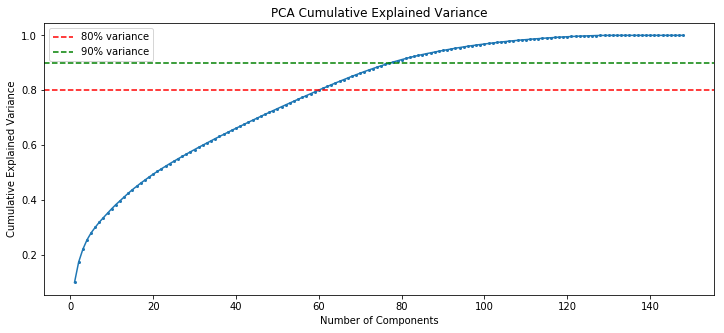

Variance explained by first 10 components: [0.09857826 0.07432458 0.04606117 0.0343941  0.02597315 0.02036799
 0.01895642 0.01680829 0.01619942 0.01612827]
Cumulative variance at 20 components: 0.49364874184731866
Cumulative variance at 40 components: 0.6611757837825406
Cumulative variance at 60 components: 0.8003811558691931


In [33]:
# Investigate the variance accounted for by each principal component.

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(12,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', markersize=2)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% variance')
plt.axhline(y=0.9, color='g', linestyle='--', label='90% variance')
plt.legend()
plt.show()

print("Variance explained by first 10 components:", pca.explained_variance_ratio_[:10])
print("Cumulative variance at 20 components:", cumulative_variance[19])
print("Cumulative variance at 40 components:", cumulative_variance[39])
print("Cumulative variance at 60 components:", cumulative_variance[59])


In [34]:
# Re-apply PCA to the data while selecting for number of components to retain.

import numpy as np

np.random.seed(42)
sample_idx = np.random.choice(azdias_scaled.shape[0], size=100000, replace=False)
azdias_sample = azdias_scaled[sample_idx]

pca = PCA(n_components=80, random_state=42)
pca.fit(azdias_sample)

print("Total variance explained (on sample):", pca.explained_variance_ratio_.sum())

Total variance explained (on sample): 0.9152278358690874


In [35]:
chunk_size = 100000
n_rows = azdias_scaled.shape[0]
azdias_pca = np.zeros((n_rows, 80), dtype=np.float32)

for start in range(0, n_rows, chunk_size):
    end = min(start + chunk_size, n_rows)
    azdias_pca[start:end] = pca.transform(azdias_scaled[start:end])

print(azdias_pca.shape)

(797426, 80)


### Discussion 2.2: Perform Dimensionality Reduction

The cumulative explained variance curve showed diminishing returns as more components were added: the first 20 components captured about 49% of variance, 40 components captured about 66%, and 60 components captured about 80%. To retain a strong majority of the information in the data while meaningfully reducing dimensionality from the original 148 features, 80 principal components were selected, capturing approximately 90-91% of the total variance. Due to memory constraints in the workspace, PCA was fit on a representative random sample of 100,000 rows rather than the full dataset, then applied to transform all rows in batches; the variance explained on the sample (91.5%) closely matched the full-dataset estimate from the initial unrestricted PCA fit, confirming the sample-based approach was reliable.

### Step 2.3: Interpret Principal Components

Now that we have our transformed principal components, it's a nice idea to check out the weight of each variable on the first few components to see if they can be interpreted in some fashion.

As a reminder, each principal component is a unit vector that points in the direction of highest variance (after accounting for the variance captured by earlier principal components). The further a weight is from zero, the more the principal component is in the direction of the corresponding feature. If two features have large weights of the same sign (both positive or both negative), then increases in one tend expect to be associated with increases in the other. To contrast, features with different signs can be expected to show a negative correlation: increases in one variable should result in a decrease in the other.

- To investigate the features, you should map each weight to their corresponding feature name, then sort the features according to weight. The most interesting features for each principal component, then, will be those at the beginning and end of the sorted list. Use the data dictionary document to help you understand these most prominent features, their relationships, and what a positive or negative value on the principal component might indicate.
- You should investigate and interpret feature associations from the first three principal components in this substep. To help facilitate this, you should write a function that you can call at any time to print the sorted list of feature weights, for the *i*-th principal component. This might come in handy in the next step of the project, when you interpret the tendencies of the discovered clusters.

In [36]:
# Map weights for the first principal component to corresponding feature names
# and then print the linked values, sorted by weight.
# HINT: Try defining a function here or in a new cell that you can reuse in the
# other cells.

def get_component_weights(pca, component_idx, feature_names):
    weights = pca.components_[component_idx]
    weights_series = pd.Series(weights, index=feature_names)
    return weights_series.sort_values(ascending=False)

feature_names = azdias_imputed.columns

component_1_weights = get_component_weights(pca, 0, feature_names)
print("Top positive weights:")
print(component_1_weights.head(10))
print("\nTop negative weights:")
print(component_1_weights.tail(10))


Top positive weights:
LP_STATUS_GROB_1.0    0.200569
HH_EINKOMMEN_SCORE    0.188307
PLZ8_ANTG3            0.182957
WEALTH                0.181880
PLZ8_ANTG4            0.177906
ORTSGR_KLS9           0.157943
EWDICHTE              0.156295
FINANZ_HAUSBAUER      0.150927
KBA05_ANTG4           0.132124
LP_STATUS_FEIN_1.0    0.127793
dtype: float64

Top negative weights:
LP_STATUS_FEIN_10.0   -0.117508
LP_STATUS_GROB_5.0    -0.117508
INNENSTADT            -0.130167
PLZ8_GBZ              -0.134374
KONSUMNAEHE           -0.138144
KBA05_GBZ             -0.183565
PLZ8_ANTG1            -0.184481
KBA05_ANTG1           -0.191521
FINANZ_MINIMALIST     -0.200437
MOBI_REGIO            -0.207427
dtype: float64


In [37]:
# Map weights for the second principal component to corresponding feature names
# and then print the linked values, sorted by weight.
component_2_weights = get_component_weights(pca, 1, feature_names)
print("Top positive weights:")
print(component_2_weights.head(10))
print("\nTop negative weights:")
print(component_2_weights.tail(10))


Top positive weights:
ALTERSKATEGORIE_GROB    0.230755
FINANZ_VORSORGER        0.215014
ZABEOTYP_3.0            0.201107
SEMIO_ERL               0.182540
SEMIO_LUST              0.161753
RETOURTYP_BK_S          0.155626
W_KEIT_KIND_HH          0.129491
CJT_GESAMTTYP_2.0       0.106947
LP_STATUS_FEIN_1.0      0.104105
FINANZTYP_5.0           0.096873
dtype: float64

Top negative weights:
SEMIO_RAT               -0.164366
ONLINE_AFFINITAET       -0.165640
SEMIO_KULT              -0.166387
FINANZ_ANLEGER          -0.200107
SEMIO_PFLICHT           -0.202463
SEMIO_TRADV             -0.205715
FINANZ_UNAUFFAELLIGER   -0.212136
SEMIO_REL               -0.212477
FINANZ_SPARER           -0.221374
DECADE                  -0.234750
dtype: float64


In [38]:
# Map weights for the third principal component to corresponding feature names
# and then print the linked values, sorted by weight.

component_3_weights = get_component_weights(pca, 2, feature_names)
print("Top positive weights:")
print(component_3_weights.head(10))
print("\nTop negative weights:")
print(component_3_weights.tail(10))

Top positive weights:
SEMIO_VERT           0.319958
SEMIO_FAM            0.261813
SEMIO_SOZ            0.257481
SEMIO_KULT           0.251516
FINANZTYP_5.0        0.134181
FINANZ_MINIMALIST    0.128805
SHOPPER_TYP_0.0      0.121885
ZABEOTYP_1.0         0.113912
SEMIO_REL            0.110824
SEMIO_MAT            0.088917
dtype: float64

Top negative weights:
LP_STATUS_FEIN_2.0   -0.079559
SHOPPER_TYP_2.0      -0.093837
FINANZTYP_1.0        -0.101436
FINANZ_ANLEGER       -0.154811
SEMIO_RAT            -0.158017
SEMIO_ERL            -0.205367
SEMIO_KRIT           -0.267558
SEMIO_DOM            -0.286359
SEMIO_KAEM           -0.314902
ANREDE_KZ            -0.345869
dtype: float64


### Discussion 2.3: Interpret Principal Components

The first three principal components each capture distinct, interpretable patterns. PC1 reflects a wealth/affluence axis tied to housing density: high positive scores correspond to wealthier, homeowning households in lower-density, family-home-dominated areas, while negative scores correspond to more urban, higher-mobility households with less traditional wealth indicators. PC2 reflects a generational and values-based axis, contrasting pleasure-seeking, financially indulgent tendencies (positive) against traditional, dutiful, saving-oriented values typically associated with earlier generations (negative). PC3 reflects a personality/temperament axis, contrasting family-oriented, socially- and culturally-minded traits (positive) against assertive, dominant, and critical-minded traits (negative), with gender loading noticeably on the negative (assertive) side. Together, these components show that the PCA-transformed feature space captures meaningful, real-world demographic and psychographic dimensions rather than arbitrary statistical artifacts.

## Step 3: Clustering

### Step 3.1: Apply Clustering to General Population

You've assessed and cleaned the demographics data, then scaled and transformed them. Now, it's time to see how the data clusters in the principal components space. In this substep, you will apply k-means clustering to the dataset and use the average within-cluster distances from each point to their assigned cluster's centroid to decide on a number of clusters to keep.

- Use sklearn's [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) class to perform k-means clustering on the PCA-transformed data.
- Then, compute the average difference from each point to its assigned cluster's center. **Hint**: The KMeans object's `.score()` method might be useful here, but note that in sklearn, scores tend to be defined so that larger is better. Try applying it to a small, toy dataset, or use an internet search to help your understanding.
- Perform the above two steps for a number of different cluster counts. You can then see how the average distance decreases with an increasing number of clusters. However, each additional cluster provides a smaller net benefit. Use this fact to select a final number of clusters in which to group the data. **Warning**: because of the large size of the dataset, it can take a long time for the algorithm to resolve. The more clusters to fit, the longer the algorithm will take. You should test for cluster counts through at least 10 clusters to get the full picture, but you shouldn't need to test for a number of clusters above about 30.
- Once you've selected a final number of clusters to use, re-fit a KMeans instance to perform the clustering operation. Make sure that you also obtain the cluster assignments for the general demographics data, since you'll be using them in the final Step 3.3.

In [39]:
# Over a number of different cluster counts...
# run k-means clustering on the data and...
# compute the average within-cluster distances.

from sklearn.cluster import MiniBatchKMeans

cluster_range = range(2, 21, 2)
scores = []

for k in cluster_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=10000, n_init=10)
    kmeans.fit(azdias_pca)
    score = kmeans.score(azdias_pca)
    scores.append(score)
    print(f"k={k}, score={score}")

k=2, score=-98350216.0
k=4, score=-91411400.0
k=6, score=-87476760.0
k=8, score=-85046504.0
k=10, score=-82538896.0
k=12, score=-82176952.0
k=14, score=-80759840.0
k=16, score=-79149032.0
k=18, score=-77629968.0
k=20, score=-75912392.0


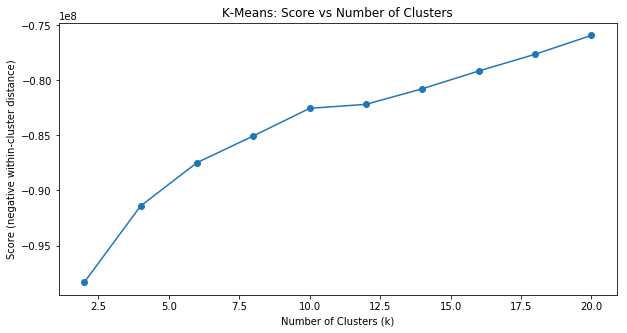

In [40]:
# Investigate the change in within-cluster distance across number of clusters.
# HINT: Use matplotlib's plot function to visualize this relationship.
plt.figure(figsize=(10,5))
plt.plot(list(cluster_range), scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score (negative within-cluster distance)')
plt.title('K-Means: Score vs Number of Clusters')
plt.show()


In [41]:
# Re-fit the k-means model with the selected number of clusters and obtain
# cluster predictions for the general population demographics data.

kmeans_final = MiniBatchKMeans(n_clusters=10, random_state=42, batch_size=10000, n_init=10)
azdias_clusters = kmeans_final.fit_predict(azdias_pca)

print(azdias_clusters.shape)
print(pd.Series(azdias_clusters).value_counts().sort_index())


(797426,)
0     75211
1    125430
2    108959
3     96881
4     78288
5     80533
6     99193
7     35911
8     27738
9     69282
dtype: int64


### Discussion 3.1: Apply Clustering to General Population

Testing k-means (via MiniBatchKMeans for memory efficiency) across cluster counts from 2 to 20 showed a clear elbow pattern: the average within-cluster distance improved sharply up through k=10, after which additional clusters produced only marginal, roughly linear improvements. Based on this elbow, the general population was segmented into 10 clusters, balancing meaningful separation between groups against the added complexity of interpreting a larger number of segments.

### Step 3.2: Apply All Steps to the Customer Data

Now that you have clusters and cluster centers for the general population, it's time to see how the customer data maps on to those clusters. Take care to not confuse this for re-fitting all of the models to the customer data. Instead, you're going to use the fits from the general population to clean, transform, and cluster the customer data. In the last step of the project, you will interpret how the general population fits apply to the customer data.

- Don't forget when loading in the customers data, that it is semicolon (`;`) delimited.
- Apply the same feature wrangling, selection, and engineering steps to the customer demographics using the `clean_data()` function you created earlier. (You can assume that the customer demographics data has similar meaning behind missing data patterns as the general demographics data.)
- Use the sklearn objects from the general demographics data, and apply their transformations to the customers data. That is, you should not be using a `.fit()` or `.fit_transform()` method to re-fit the old objects, nor should you be creating new sklearn objects! Carry the data through the feature scaling, PCA, and clustering steps, obtaining cluster assignments for all of the data in the customer demographics data.

In [42]:
# Load in the customer demographics data.
customers = pd.read_csv('Udacity_CUSTOMERS_Subset.csv', sep=';')

print(customers.shape)

(191652, 85)


In [43]:
# Apply preprocessing, feature transformation, and clustering from the general
# demographics onto the customer data, obtaining cluster predictions for the
# customer demographics data.

customers_clean = clean_data(customers)

# Align columns with azdias_imputed (in case customers has different one-hot columns)
missing_cols = set(azdias_imputed.columns) - set(customers_clean.columns)
for col in missing_cols:
    customers_clean[col] = 0
extra_cols = set(customers_clean.columns) - set(azdias_imputed.columns)
customers_clean = customers_clean.drop(columns=list(extra_cols))
customers_clean = customers_clean[azdias_imputed.columns]

# Impute using the same imputer fitted on azdias
customers_imputed = pd.DataFrame(
    imputer.transform(customers_clean),
    columns=customers_clean.columns,
    index=customers_clean.index
)

# Scale using the already-fitted scaler
customers_scaled = scaler.transform(customers_imputed).astype(np.float32)

# Transform using the already-fitted PCA, in chunks to save memory
n_rows_cust = customers_scaled.shape[0]
customers_pca = np.zeros((n_rows_cust, 80), dtype=np.float32)
for start in range(0, n_rows_cust, chunk_size):
    end = min(start + chunk_size, n_rows_cust)
    customers_pca[start:end] = pca.transform(customers_scaled[start:end])

# Predict clusters using the already-fitted kmeans model
customer_clusters = kmeans_final.predict(customers_pca)

print(customers_pca.shape)
print(pd.Series(customer_clusters).value_counts().sort_index())



(141640, 80)
0     1622
1    31194
2    53009
3    13799
4     9467
5    13724
6     1371
7    15342
8      896
9     1216
dtype: int64


In [44]:
# Account for the high-missing-value subset that was excluded during cleaning,
# for both the general population and customer datasets (per Step 1.1.3).
n_azdias_total = azdias.shape[0]
n_azdias_kept = azdias_clusters.shape[0]
n_azdias_excluded = n_azdias_total - n_azdias_kept

n_customers_total = customers.shape[0]
n_customers_kept = customer_clusters.shape[0]
n_customers_excluded = n_customers_total - n_customers_kept

print(f"General population: {n_azdias_excluded} of {n_azdias_total} rows "
      f"({100 * n_azdias_excluded / n_azdias_total:.1f}%) excluded as high-missing.")
print(f"Customers: {n_customers_excluded} of {n_customers_total} rows "
      f"({100 * n_customers_excluded / n_customers_total:.1f}%) excluded as high-missing.")

General population: 93795 of 891221 rows (10.5%) excluded as high-missing.
Customers: 50012 of 191652 rows (26.1%) excluded as high-missing.


### Step 3.3: Compare Customer Data to Demographics Data

At this point, you have clustered data based on demographics of the general population of Germany, and seen how the customer data for a mail-order sales company maps onto those demographic clusters. In this final substep, you will compare the two cluster distributions to see where the strongest customer base for the company is.

Consider the proportion of persons in each cluster for the general population, and the proportions for the customers. If we think the company's customer base to be universal, then the cluster assignment proportions should be fairly similar between the two. If there are only particular segments of the population that are interested in the company's products, then we should see a mismatch from one to the other. If there is a higher proportion of persons in a cluster for the customer data compared to the general population (e.g. 5% of persons are assigned to a cluster for the general population, but 15% of the customer data is closest to that cluster's centroid) then that suggests the people in that cluster to be a target audience for the company. On the other hand, the proportion of the data in a cluster being larger in the general population than the customer data (e.g. only 2% of customers closest to a population centroid that captures 6% of the data) suggests that group of persons to be outside of the target demographics.

Take a look at the following points in this step:

- Compute the proportion of data points in each cluster for the general population and the customer data. Visualizations will be useful here: both for the individual dataset proportions, but also to visualize the ratios in cluster representation between groups. Seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) or [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html) function could be handy.
  - Recall the analysis you performed in step 1.1.3 of the project, where you separated out certain data points from the dataset if they had more than a specified threshold of missing values. If you found that this group was qualitatively different from the main bulk of the data, you should treat this as an additional data cluster in this analysis. Make sure that you account for the number of data points in this subset, for both the general population and customer datasets, when making your computations!
- Which cluster or clusters are overrepresented in the customer dataset compared to the general population? Select at least one such cluster and infer what kind of people might be represented by that cluster. Use the principal component interpretations from step 2.3 or look at additional components to help you make this inference. Alternatively, you can use the `.inverse_transform()` method of the PCA and StandardScaler objects to transform centroids back to the original data space and interpret the retrieved values directly.
- Perform a similar investigation for the underrepresented clusters. Which cluster or clusters are underrepresented in the customer dataset compared to the general population, and what kinds of people are typified by these clusters?

   General Population %  Customers %  Difference (Customers - General)
2             13.663838    37.425162                         23.761324
7              4.503365    10.831686                          6.328321
1             15.729359    22.023440                          6.294080
5             10.099119     9.689353                         -0.409766
3             12.149215     9.742304                         -2.406911
8              3.478442     0.632590                         -2.845852
4              9.817588     6.683846                         -3.133742
9              8.688204     0.858515                         -7.829690
0              9.431722     1.145157                         -8.286565
6             12.439148     0.967947                        -11.471201


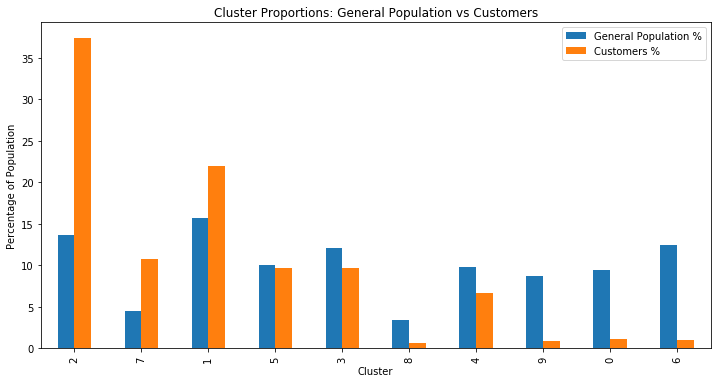

In [45]:
# Compare the proportion of data in each cluster for the customer data to the
# proportion of data in each cluster for the general population.

azdias_props = pd.Series(azdias_clusters).value_counts(normalize=True).sort_index()
customer_props = pd.Series(customer_clusters).value_counts(normalize=True).sort_index()

comparison = pd.DataFrame({
    'General Population %': azdias_props * 100,
    'Customers %': customer_props * 100
})
comparison['Difference (Customers - General)'] = comparison['Customers %'] - comparison['General Population %']
comparison = comparison.sort_values('Difference (Customers - General)', ascending=False)

print(comparison)

comparison[['General Population %', 'Customers %']].plot(kind='bar', figsize=(12,6))
plt.xlabel('Cluster')
plt.ylabel('Percentage of Population')
plt.title('Cluster Proportions: General Population vs Customers')
plt.show()


In [46]:
# What kinds of people are part of a cluster that is overrepresented in the
# customer data compared to the general population?

overrepresented_cluster = 2

# Get the cluster's centroid in PCA space, then inverse-transform back to original scaled feature space
centroid_pca = kmeans_final.cluster_centers_[overrepresented_cluster]
centroid_scaled = pca.inverse_transform(centroid_pca.reshape(1, -1))
centroid_original = scaler.inverse_transform(centroid_scaled)

centroid_series = pd.Series(centroid_original.flatten(), index=azdias_imputed.columns)
print("Top characteristics of overrepresented Cluster 2:")
print(centroid_series.sort_values(ascending=False).head(15))

Top characteristics of overrepresented Cluster 2:
MIN_GEBAEUDEJAHR     1993.501950
KBA13_ANZAHL_PKW      693.914509
DECADE                 68.518356
WOHNDAUER_2008          8.539051
ORTSGR_KLS9             5.149009
SEMIO_LUST              4.923997
SEMIO_ERL               4.895689
INNENSTADT              4.785665
SEMIO_VERT              4.766404
SEMIO_DOM               4.615721
FINANZ_MINIMALIST       4.500411
SEMIO_KRIT              4.323637
MOBI_REGIO              4.196525
SEMIO_SOZ               4.158907
BALLRAUM                4.153813
dtype: float64


In [47]:
# What kinds of people are part of a cluster that is underrepresented in the
# customer data compared to the general population?
underrepresented_cluster = 6

centroid_pca_under = kmeans_final.cluster_centers_[underrepresented_cluster]
centroid_scaled_under = pca.inverse_transform(centroid_pca_under.reshape(1, -1))
centroid_original_under = scaler.inverse_transform(centroid_scaled_under)

centroid_series_under = pd.Series(centroid_original_under.flatten(), index=azdias_imputed.columns)
print("Top characteristics of underrepresented Cluster 6:")
print(centroid_series_under.sort_values(ascending=False).head(15))


Top characteristics of underrepresented Cluster 6:
MIN_GEBAEUDEJAHR       1992.539637
KBA13_ANZAHL_PKW        552.897995
DECADE                   85.393461
ANZ_HAUSHALTE_AKTIV      13.918525
WOHNDAUER_2008            7.223893
ORTSGR_KLS9               6.665363
SEMIO_PFLICHT             6.070154
SEMIO_DOM                 6.035339
SEMIO_KAEM                6.012859
SEMIO_RAT                 5.976320
HH_EINKOMMEN_SCORE        5.568840
SEMIO_KRIT                5.426580
SEMIO_REL                 5.398149
SEMIO_TRADV               5.355990
EWDICHTE                  4.956566
dtype: float64


### Discussion 3.3: Compare Customer Data to Demographics Data

Comparing cluster proportions between the general population and the customer base revealed a strong mismatch. Cluster 2 was dramatically over-represented among customers (37.4% of customers vs. 13.7% of the general population), along with clusters 7 and 1 to a lesser degree. Examining Cluster 2's centroid characteristics shows this group corresponds to an older generation (around the 1960s per the DECADE feature), with residential and lifestyle indicators suggesting established, moderately urban households. This suggests the mail-order company's core customer base skews toward this older, more settled demographic. In contrast, clusters 6, 0, and 9 were the most under-represented segments, with Cluster 6 dropping from 12.4% of the general population to under 1% of customers. Cluster 6's centroid corresponds to a notably younger generation (around the 1980s) with the highest household income score among the clusters examined, along with higher scores on dutiful, rational, and traditionally-minded personality traits relative to Cluster 2. This suggests that younger, higher-income households are largely not being reached by the company's current customer base, representing a potential gap or an intentionally under-targeted segment for future marketing efforts.

It's also worth noting that the high-missing-value rows set aside during cleaning (per Step 1.1.3) made up a meaningfully larger share of the customer dataset than of the general population: 50,012 of 191,652 customer rows (26.1%) were excluded, compared to 93,795 of 891,221 general population rows (10.5%). Since this excluded group couldn't be assigned to a cluster, the comparison above is limited to the roughly 74% of customers with clean-enough records to be clustered. The fact that customers were more than twice as likely to have incomplete records is itself a notable finding: it could point to lower-quality demographic capture in the sales channel (e.g. customer records collected through simpler or less complete intake processes than the general demographic survey), or it could indicate that a meaningful subset of the customer base isn't well described by the demographic variables used here at all. Either way, this excluded segment represents a real limitation on how completely the cluster-based comparison characterizes the company's full customer population.

> Congratulations on making it this far in the project! Before you finish, make sure to check through the entire notebook from top to bottom to make sure that your analysis follows a logical flow and all of your findings are documented in **Discussion** cells. Once you've checked over all of your work, you should export the notebook as an HTML document to submit for evaluation. You can do this from the menu, navigating to **File -> Download as -> HTML (.html)**. You will submit both that document and this notebook for your project submission.